# 02 — stage 1 done honestly: scan 165 symbols for cointegration, then re-test OOS

This is your **stage 1 (selection)**, built to be lookahead-free. The plan:

1. Take all 165 symbols with full 2024 coverage, prices at 4h.
2. **On TRAIN (H1-2024) only**, run an Engle-Granger cointegration test on every
   one of the ~13,500 possible pairs. Keep the "significant" ones (ADF p < 0.05
   on the regression residual).
3. **Freeze β from train**, then re-test each surviving pair on **OOS (H2-2024)**.
   Count how many are *still* cointegrated.

Two traps we are explicitly measuring here, not assuming away:

- **Multiple testing.** If we run 13,500 tests at a 5% threshold, then **~675
  pairs pass by pure chance**, even if no pair is truly cointegrated. So a raw
  "we found 900 cointegrated pairs!" is almost meaningless — we must compare the
  hit count against that ~5% chance rate, and lean on OOS survival as the real
  judge.
- **Cointegration decay.** nb01 already showed one co-moving pair break OOS.
  Here we measure it at scale: of the pairs that look cointegrated on train,
  **what fraction survive** into the next 6 months? If survival ≈ 5%, train
  cointegration is noise. If it's well above 5%, there's real structure to trade.

**Glossary:**
- **Engle-Granger:** regress log(A) on log(B) (+ intercept) → the leftover
  residual is the spread; run ADF on that residual. Small p → the spread is
  stationary → the pair is cointegrated *on this window*.
- **survival rate:** P(cointegrated OOS | cointegrated on train). This is the
  number that tells us whether stage-1 selection is even worth doing.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/pairs
from _lab import *
import numpy as np, pandas as pd
from statsmodels.tsa.stattools import adfuller
import itertools, time

TF = "4h"
TRAIN_END = "2024-07-01"

syms = list_symbols()
full = [s for s in syms if coverage(s)[0] <= "2024-01" and coverage(s)[1] >= "2024-12"]
print(f"{len(full)} symbols with full 2024 coverage")

# Build one aligned log-price matrix (rows = 4h timestamps, cols = symbols).
closes = {}
for s in full:
    try:
        closes[s] = ohlcv(s, "2024-01-01", "2025-01-01", TF)["close"]
    except Exception as e:
        print("skip", s, e)
P = pd.DataFrame(closes).dropna()      # keep rows where every symbol is present
L = np.log(P)
print(f"aligned log-price matrix: {L.shape[0]} rows x {L.shape[1]} symbols "
      f"({L.index[0]} -> {L.index[-1]})")

Ltr  = L.loc[:TRAIN_END].iloc[:-1]     # train  = H1-2024
Loos = L.loc[TRAIN_END:]               # oos    = H2-2024
print(f"train {Ltr.shape[0]} bars | oos {Loos.shape[0]} bars")

165 symbols with full 2024 coverage


aligned log-price matrix: 2196 rows x 165 symbols (2024-01-01 00:00:00+00:00 -> 2024-12-31 20:00:00+00:00)
train 1097 bars | oos 1104 bars


In [2]:
# --- helpers: Engle-Granger via OLS(a~b+const) then ADF on the residual -----
# We roll our own (instead of statsmodels.coint) so train and OOS use the SAME
# frozen beta/intercept -> a clean apples-to-apples decay measurement.
def fit_spread(a, b):
    # OLS a = alpha + beta*b ; returns (alpha, beta)
    beta, alpha = np.polyfit(b, a, 1)
    return alpha, beta

def adf_p(resid):
    # fixed maxlag, no autolag search -> fast and consistent across 13k pairs
    return adfuller(resid, maxlag=6, autolag=None)[1]

def hl(resid):  # half-life in bars from AR(1) on the residual
    r = pd.Series(resid)
    lag = r.shift(1)
    d = (r - lag).dropna(); lag = lag.loc[d.index]
    bcoef = np.polyfit(lag.values, d.values, 1)[0]
    return -np.log(2)/np.log(1+bcoef) if bcoef < 0 else np.nan

pairs = list(itertools.combinations(L.columns, 2))
print(f"scanning {len(pairs)} pairs on TRAIN ...")

scanning 13530 pairs on TRAIN ...


In [3]:
# --- TRAIN scan: cointegration p-value for every pair -----------------------
t0 = time.time()
rows = []
Atr = Ltr.values; cols = list(Ltr.columns); idx = {c:i for i,c in enumerate(cols)}
for sa, sb in pairs:
    a = Atr[:, idx[sa]]; b = Atr[:, idx[sb]]
    alpha, beta = fit_spread(a, b)
    resid = a - alpha - beta*b
    rows.append((sa, sb, alpha, beta, adf_p(resid)))
res = pd.DataFrame(rows, columns=["a","b","alpha","beta","p_train"])
print(f"done in {time.time()-t0:.0f}s")

ALPHA = 0.05
n_hits = int((res.p_train < ALPHA).sum())
expected_by_chance = ALPHA * len(res)
print(f"\ntrain pairs with p<{ALPHA}: {n_hits} / {len(res)}  ({100*n_hits/len(res):.1f}%)")
print(f"expected by pure chance (5% of {len(res)}): ~{expected_by_chance:.0f}")
print(f"excess over chance: {n_hits - expected_by_chance:+.0f} "
      f"({n_hits/expected_by_chance:.2f}x the null)")

done in 4s

train pairs with p<0.05: 1886 / 13530  (13.9%)
expected by pure chance (5% of 13530): ~676
excess over chance: +1210 (2.79x the null)


In [4]:
# --- OOS re-test: freeze train beta/alpha, ADF on OOS residual --------------
sig = res[res.p_train < ALPHA].copy()
Aoos = Loos.values; idxo = {c:i for i,c in enumerate(Loos.columns)}
p_oos, hl_tr, hl_oos = [], [], []
for r in sig.itertuples():
    a_o = Aoos[:, idxo[r.a]]; b_o = Aoos[:, idxo[r.b]]
    resid_o = a_o - r.alpha - r.beta*b_o          # SAME train coefficients
    p_oos.append(adf_p(resid_o))
    hl_oos.append(hl(resid_o))
    a_t = Atr[:, idx[r.a]]; b_t = Atr[:, idx[r.b]]
    hl_tr.append(hl(a_t - r.alpha - r.beta*b_t))
sig["p_oos"] = p_oos; sig["hl_train"] = hl_tr; sig["hl_oos"] = hl_oos

survived = int((sig.p_oos < ALPHA).sum())
print(f"of {len(sig)} train-cointegrated pairs, {survived} still cointegrated OOS "
      f"= {100*survived/len(sig):.1f}% survival")
print(f"chance baseline if train-selection were noise: ~{100*ALPHA:.0f}%")
print(f"  -> survival is {survived/(ALPHA*len(sig)):.2f}x the chance rate")

of 1886 train-cointegrated pairs, 236 still cointegrated OOS = 12.5% survival
chance baseline if train-selection were noise: ~5%
  -> survival is 2.50x the chance rate


In [5]:
# --- The survivors: lowest combined train+oos p, sensible half-life ---------
surv = sig[(sig.p_oos < ALPHA)].copy()
surv["p_max"] = surv[["p_train","p_oos"]].max(axis=1)   # both must be small
top = surv.sort_values("p_max").head(20)
pd.set_option("display.width", 140, "display.max_columns", 20)
print("top 20 pairs cointegrated on BOTH train and OOS:\n")
print(top[["a","b","beta","p_train","p_oos","hl_train","hl_oos"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

top 20 pairs cointegrated on BOTH train and OOS:

          a         b  beta  p_train  p_oos  hl_train  hl_oos
    GMTUSDT  KAVAUSDT 0.942    0.000  0.000    33.021  29.199
    GMTUSDT   WOOUSDT 0.738    0.001  0.000    35.298  27.799
   SANDUSDT  SCRTUSDT 0.834    0.001  0.000    20.263  21.317
   IOTAUSDT  SANDUSDT 0.925    0.001  0.000    19.272  28.151
   QTUMUSDT STEEMUSDT 1.174    0.002  0.003    13.885  17.243
    MTLUSDT  WAXPUSDT 0.777    0.003  0.000    23.345   8.416
    JSTUSDT  SCRTUSDT 0.445    0.002  0.004    28.013  29.255
     SCUSDT   WOOUSDT 0.871    0.004  0.004    43.957  27.165
    GMTUSDT   SNXUSDT 0.826    0.000  0.004    26.137  38.715
    GMTUSDT   OGNUSDT 0.881    0.000  0.004    28.578  25.365
   KAVAUSDT   SKLUSDT 0.873    0.001  0.004    26.998  18.536
    GMTUSDT   SKLUSDT 0.813    0.002  0.004    36.154  32.003
    GMTUSDT  POWRUSDT 0.859    0.000  0.004    18.776  34.152
    BATUSDT   ZILUSDT 0.737    0.001  0.005    13.512  22.438
   DASHUSDT  SCRTUSD

[saved] notebooks\pairs\_out\02_coint_train_vs_oos.png


WindowsPath('C:/projects/researchlab/notebooks/pairs/_out/02_coint_train_vs_oos.png')

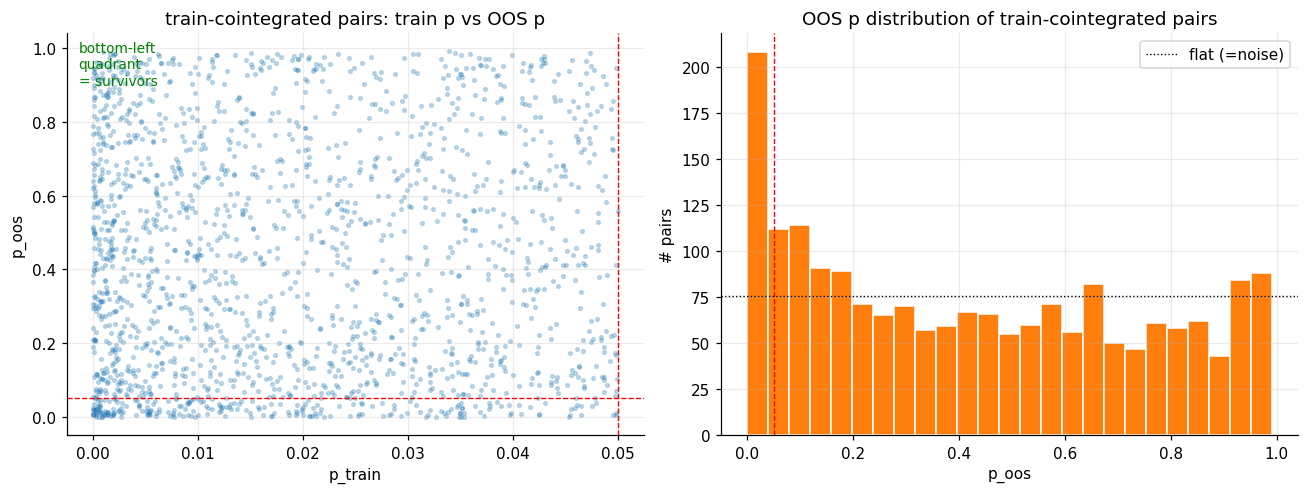

In [6]:
# --- Picture: p_train vs p_oos (does train significance predict OOS?) -------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

ax[0].scatter(sig.p_train, sig.p_oos, s=6, alpha=0.25, color="C0")
ax[0].axhline(ALPHA, color="r", lw=0.9, ls="--"); ax[0].axvline(ALPHA, color="r", lw=0.9, ls="--")
ax[0].set_xlabel("p_train"); ax[0].set_ylabel("p_oos")
ax[0].set_title("train-cointegrated pairs: train p vs OOS p")
ax[0].text(0.02, 0.98, "bottom-left\nquadrant\n= survivors",
           transform=ax[0].transAxes, va="top", fontsize=9, color="green")

# OOS p-value distribution. If train-selection were pure noise, OOS p would be
# ~Uniform(0,1) -> flat. A spike near 0 = real cointegration structure survives.
ax[1].hist(sig.p_oos, bins=25, color="C1", edgecolor="w")
ax[1].axvline(ALPHA, color="r", lw=0.9, ls="--")
ax[1].axhline(len(sig)/25, color="k", lw=0.9, ls=":", label="flat (=noise)")
ax[1].set_xlabel("p_oos"); ax[1].set_ylabel("# pairs")
ax[1].set_title("OOS p distribution of train-cointegrated pairs")
ax[1].legend()
show("02_coint_train_vs_oos")

### How to read this
- **Left scatter:** each dot is a pair that passed on train. x = its train p, y =
  its OOS p. The **bottom-left box** (both < 0.05, red lines) are the survivors.
  If cointegration were sticky, dots would hug the bottom; if it decays, they
  scatter up toward y=1.
- **Right histogram:** OOS p-values of the train-winners. The dotted line is what
  a **pure-noise** result would look like (flat / uniform — train significance
  tells you nothing about OOS). A **spike near 0** means train selection genuinely
  carries real cointegration forward; a flat shape means it's mostly luck.

Verdict to read off the numbers: survival rate vs the 5% chance baseline tells us
whether stage-1 selection is worth doing at all — and the survivor table is our
candidate pool for stage-2 (signals), which is the next notebook.